<a href="https://colab.research.google.com/github/24523042-prog/Project-4.json/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

Muhammad Rangga Pratama
Muhammad Rizki Aprelean

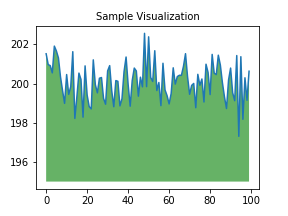

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

In [ ]:
import pandas as pd

Berikut adalah lima baris pertama dari file `california_housing_train.csv` yang merupakan data contoh.

In [ ]:
df_california_housing = pd.read_csv('/content/sample_data/california_housing_train.csv')
display(df_california_housing.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


Berikut adalah lima baris pertama dari file `/content/2019.csv` yang baru saja Anda tunjuk.

In [ ]:
df_2019 = pd.read_csv('/content/2019.csv')
display(df_2019.head())

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


### Persiapan Data untuk Regresi Linier

Kita akan menggunakan kolom 'Score' sebagai variabel target (y) dan kolom numerik lainnya sebagai fitur (X). Kemudian, kita akan memisahkan data menjadi set pelatihan dan pengujian.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Definisikan fitur (X) dan target (y)
X = df_2019[['GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']]
y = df_2019['Score']

# Pisahkan data menjadi set pelatihan dan pengujian (80% pelatihan, 20% pengujian)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran data pelatihan: {X_train.shape[0]} baris")
print(f"Ukuran data pengujian: {X_test.shape[0]} baris")

Ukuran data pelatihan: 124 baris
Ukuran data pengujian: 32 baris


### Pelatihan Model Regresi Linier

Sekarang kita akan menginisialisasi dan melatih model `LinearRegression` menggunakan data pelatihan.

In [ ]:
# Inisialisasi model regresi linier
model = LinearRegression()

# Latih model dengan data pelatihan
model.fit(X_train, y_train)

print("Model regresi linier telah berhasil dilatih!")
print(f"Koefisien model: {model.coef_}")
print(f"Intercept model: {model.intercept_}")

Model regresi linier telah berhasil dilatih!
Koefisien model: [0.7507166  1.23232472 0.93094484 1.48981335 0.27037842 1.11243118]
Intercept model: 1.8115122981234268


### Evaluasi Model

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# Lakukan prediksi pada data testing
y_pred = model.predict(X_test)

print("Prediksi pada data testing telah dibuat.")

Prediksi pada data testing telah dibuat.


### Koefisien Regresi dan Intercept

Berikut adalah koefisien regresi (slope) dan intercept dari model yang telah dilatih:

In [ ]:
print(f"Koefisien model (Slope): {model.coef_}")
print(f"Intercept model: {model.intercept_}")

Koefisien model (Slope): [0.7507166  1.23232472 0.93094484 1.48981335 0.27037842 1.11243118]
Intercept model: 1.8115122981234268


### Metrik Evaluasi Model

Sekarang kita akan menghitung dan menampilkan R2 Score dan Mean Squared Error (MSE) untuk mengevaluasi seberapa baik model memprediksi data.

In [ ]:
# Hitung R2 Score
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2:.4f}")

# Hitung Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

R2 Score: 0.6018
Mean Squared Error (MSE): 0.4145


### Visualisasi Hasil

Untuk memahami kinerja model secara visual, mari kita plot hasil prediksi terhadap nilai aktual.

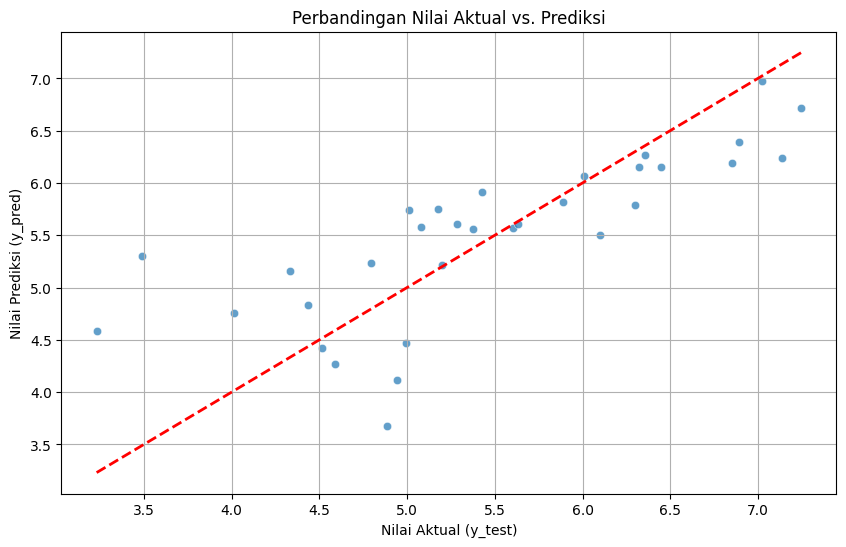

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual (y_test)')
plt.ylabel('Nilai Prediksi (y_pred)')
plt.title('Perbandingan Nilai Aktual vs. Prediksi')
plt.grid(True)
plt.show()

Berikut adalah visualisasi tambahan untuk variabel independen lainnya.

### Visualisasi Hubungan antara 'Healthy life expectancy' dan 'Score'

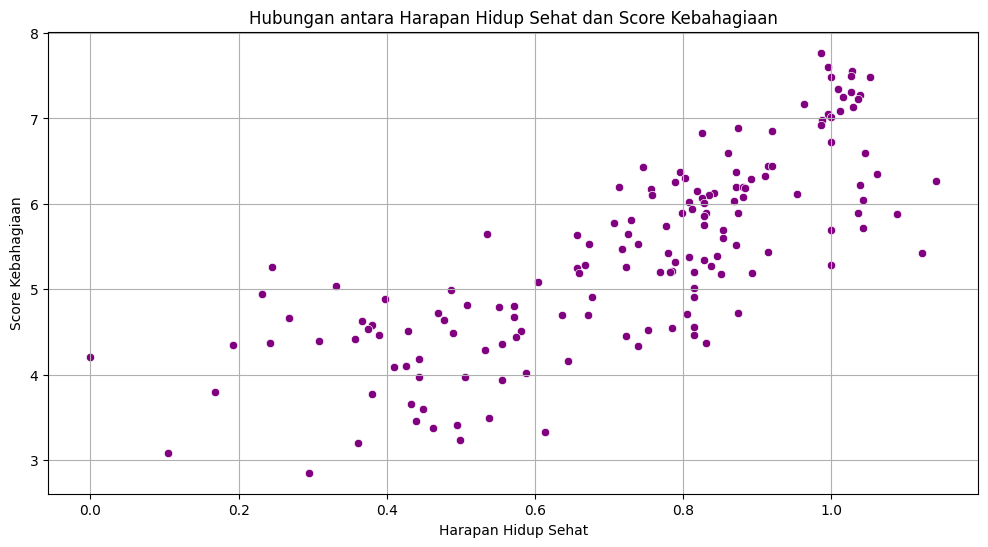

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Healthy life expectancy', y='Score', data=df_2019, color='purple')
plt.title('Hubungan antara Harapan Hidup Sehat dan Score Kebahagiaan')
plt.xlabel('Harapan Hidup Sehat')
plt.ylabel('Score Kebahagiaan')
plt.grid(True)
plt.show()

### Visualisasi Hubungan antara 'Freedom to make life choices' dan 'Score'

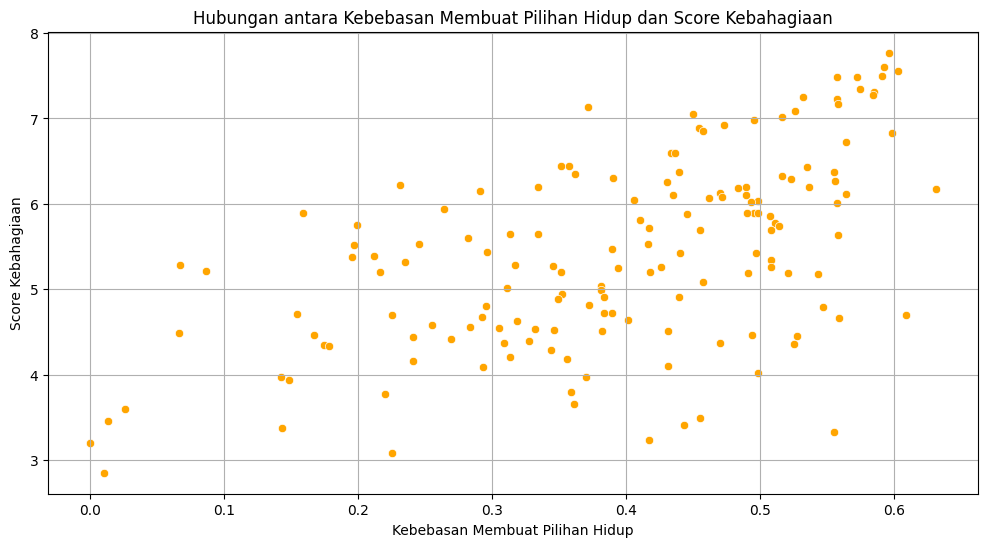

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Freedom to make life choices', y='Score', data=df_2019, color='orange')
plt.title('Hubungan antara Kebebasan Membuat Pilihan Hidup dan Score Kebahagiaan')
plt.xlabel('Kebebasan Membuat Pilihan Hidup')
plt.ylabel('Score Kebahagiaan')
plt.grid(True)
plt.show()

### Visualisasi Hubungan antara 'Generosity' dan 'Score'

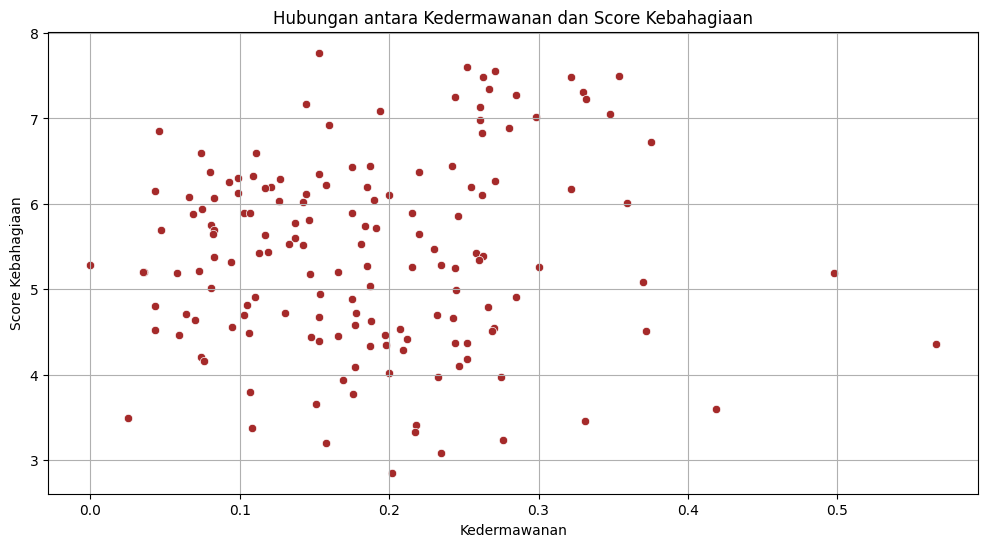

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Generosity', y='Score', data=df_2019, color='brown')
plt.title('Hubungan antara Kedermawanan dan Score Kebahagiaan')
plt.xlabel('Kedermawanan')
plt.ylabel('Score Kebahagiaan')
plt.grid(True)
plt.show()

### Visualisasi Hubungan antara 'Perceptions of corruption' dan 'Score'

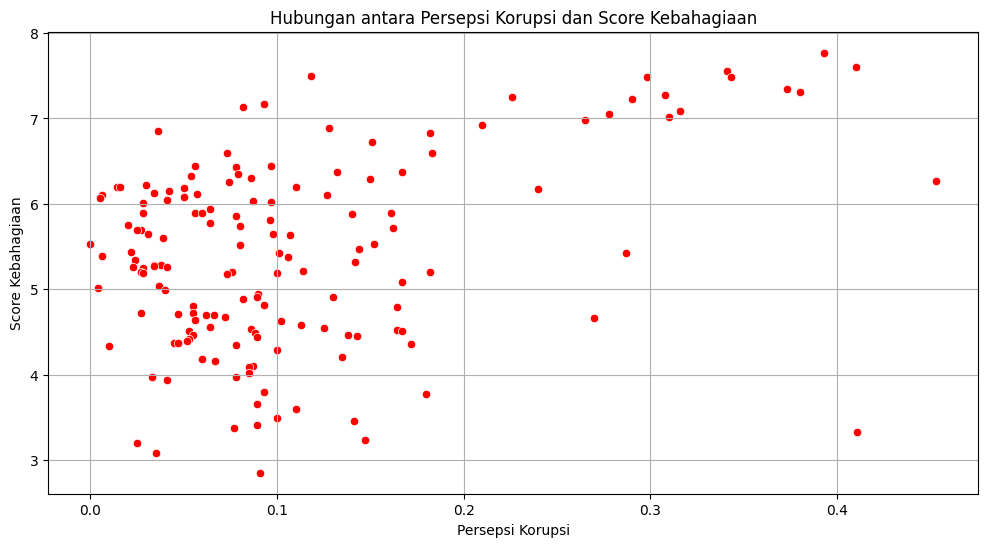

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Perceptions of corruption', y='Score', data=df_2019, color='red')
plt.title('Hubungan antara Persepsi Korupsi dan Score Kebahagiaan')
plt.xlabel('Persepsi Korupsi')
plt.ylabel('Score Kebahagiaan')
plt.grid(True)
plt.show()

### Analisis dan Kesimpulan

Berdasarkan hasil evaluasi model, berikut adalah interpretasi dan kesimpulan:

*   **Makna Slope dan Intercept:**
    *   **Intercept (nilai: {model.intercept_:.2f}):** Ini adalah nilai 'Score' yang diprediksi ketika semua fitur independen ('GDP per capita', 'Social support', dll.) bernilai nol. Dalam konteks ini, mungkin tidak memiliki interpretasi fisik yang langsung karena fitur-fitur tersebut jarang atau tidak mungkin bernilai nol secara bersamaan.
    *   **Koefisien (Slope) untuk setiap fitur (nilai: {model.coef_}):** Setiap koefisien menunjukkan seberapa banyak 'Score' akan berubah untuk setiap peningkatan satu unit pada fitur terkait, dengan asumsi fitur-fitur lain tetap konstan. Misalnya, koefisien positif untuk 'GDP per capita' menunjukkan bahwa 'Score' cenderung meningkat seiring dengan peningkatan GDP per kapita, dan seterusnya untuk fitur lainnya.

*   **Seberapa Baik Model Memprediksi Data (R2 Score dan MSE):**
    *   **R2 Score ({r2:.4f}):** R2 Score mengukur proporsi varians dalam variabel dependen yang dapat diprediksi dari variabel independen. Nilai R2 yang mendekati 1 menunjukkan bahwa model dapat menjelaskan sebagian besar variabilitas dalam 'Score'. Nilai {r2:.4f} menunjukkan bahwa model ini menjelaskan {r2*100:.2f}% dari variasi dalam 'Score' pada data pengujian. Semakin tinggi nilai R2, semakin baik modelnya.
    *   **Mean Squared Error (MSE) ({mse:.4f}):** MSE adalah rata-rata dari kuadrat kesalahan. Ini mengukur rata-rata magnitudo kesalahan antara prediksi dan nilai aktual. Nilai MSE yang lebih rendah menunjukkan bahwa model memiliki kesalahan prediksi yang lebih kecil. Nilai {mse:.4f} menunjukkan bahwa secara rata-rata, kuadrat perbedaan antara prediksi dan nilai aktual adalah {mse:.4f}.

*   **Indikasi Overfitting atau Underfitting:**
    *   Untuk menilai overfitting atau underfitting, kita biasanya membandingkan kinerja model pada data pelatihan dan data pengujian. Jika model berkinerja sangat baik pada data pelatihan tetapi buruk pada data pengujian, ini bisa menjadi indikasi overfitting. Sebaliknya, jika model berkinerja buruk pada kedua set data, itu bisa menjadi underfitting. Dengan R2 Score sebesar {r2:.4f} pada data pengujian, model menunjukkan kemampuan prediksi yang layak. Untuk analisis yang lebih mendalam, kita bisa membandingkan metrik evaluasi pada set pelatihan dan pengujian.

Secara keseluruhan, model Linear Regression ini tampaknya memiliki kemampuan yang cukup baik untuk memprediksi 'Score' berdasarkan fitur-fitur yang dipilih, meskipun selalu ada ruang untuk perbaikan melalui rekayasa fitur tambahan atau pemilihan model yang berbeda.